<a href="https://colab.research.google.com/github/Santosdevbjj/deteccao-de-anomalias-em-transacoes-em-python/blob/main/Notebooks/transacoesCartaoCredito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Carregando o conjunto de dados...

--- Dimensões do Dataset ---
Linhas: 284807, Colunas: 31

--- Distribuição das Classes ---
Class
0    284315
1       492
Name: count, dtype: int64

--- Proporção de Fraudes (%) ---
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


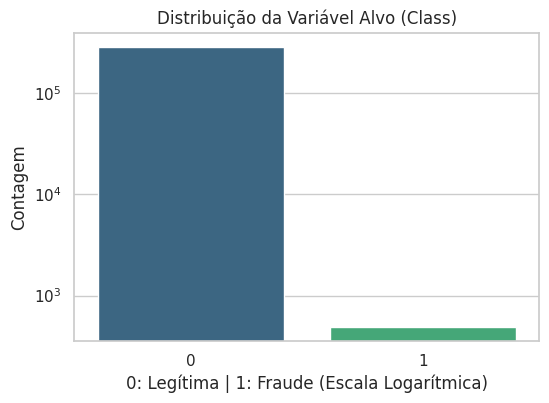


--- Separação concluída ---
X_train: (227845, 30) | X_test: (56962, 30)
Taxa de fraude no Treino: 0.00173
Taxa de fraude no Teste:  0.00172

Treinando Logistic Regression...

Treinando Random Forest...

Treinando XGBoost...

==================== RELATÓRIO: Logistic Regression ====================
              precision    recall  f1-score   support

           0     0.9999    0.9753    0.9874     56864
           1     0.0601    0.9184    0.1129        98

    accuracy                         0.9752     56962
   macro avg     0.5300    0.9468    0.5501     56962
weighted avg     0.9982    0.9752    0.9859     56962

AUPRC (Área Sob a Curva Precision-Recall): 0.7113

==================== RELATÓRIO: Random Forest ====================
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9610    0.7551    0.8457        98

    accuracy                         0.9995     56962
   macro avg     0.9803    0.8775    0

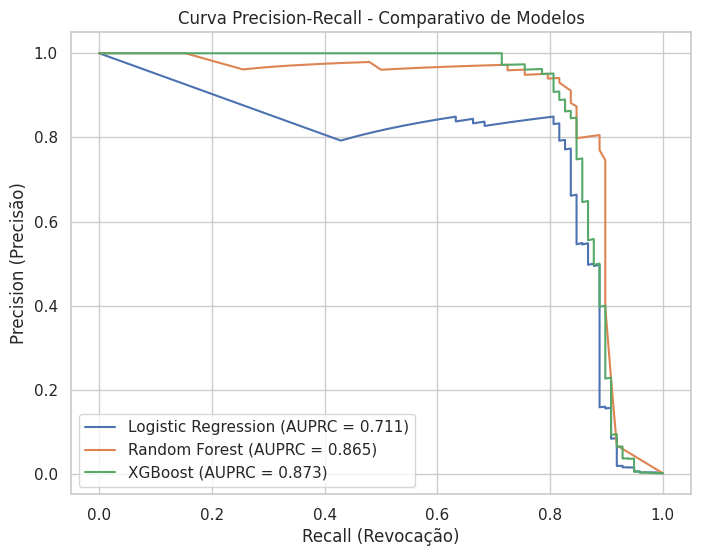


==================== XGBoost (Limiar Otimizado = 0.15) ====================
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8218    0.8469    0.8342        98

    accuracy                         0.9994     56962
   macro avg     0.9108    0.9233    0.9169     56962
weighted avg     0.9994    0.9994    0.9994     56962



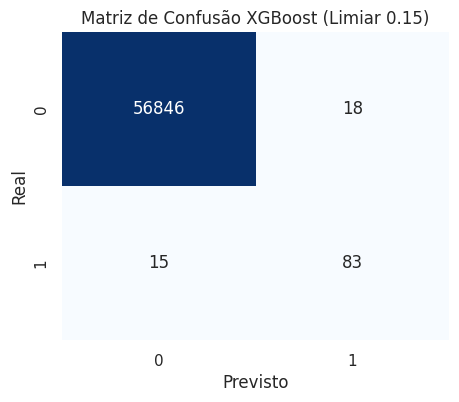


Gerando explicações globais com SHAP...


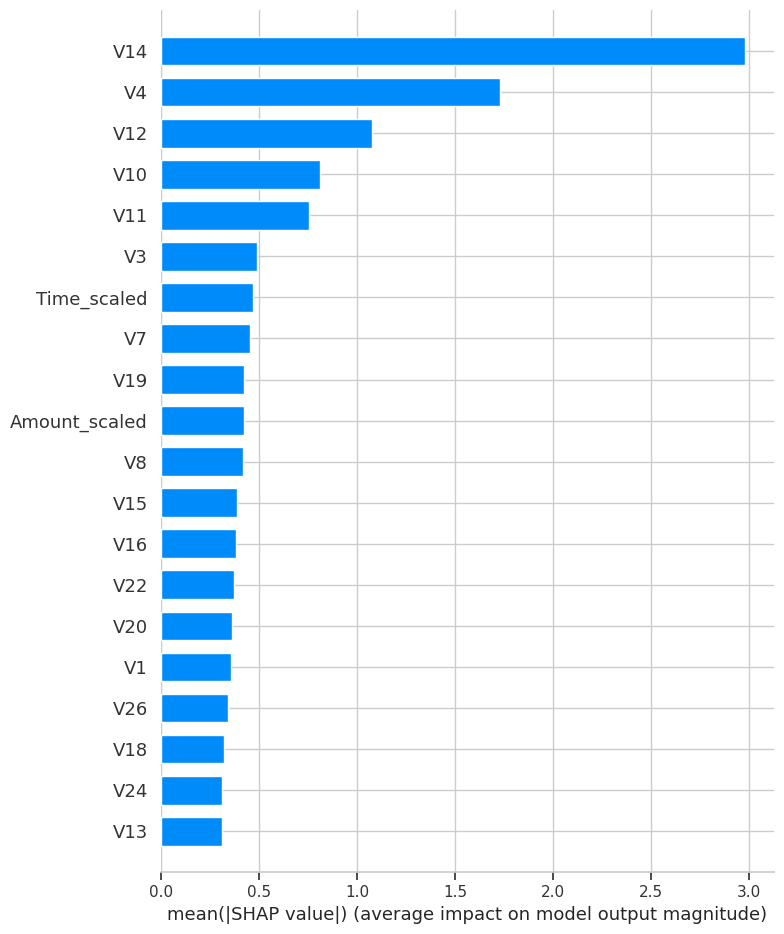

In [3]:

# ==============================================================================
# Detecção de Anomalias e Fraudes em Cartões de Crédito
# Autor: Santosdevbjj
# Projeto: Repositório de Detecção de Anomalias em Transações
# ==============================================================================

import warnings
warnings.filterwarnings('ignore') # Silencia avisos de depreciação não críticos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap

# Configurações globais
sns.set_theme(style="whitegrid")
SEED = 42
np.random.seed(SEED)

# ==============================================================================
# 1. Coleta e Análise Exploratória dos Dados (EDA)
# ==============================================================================
DATA_URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
print("Carregando o conjunto de dados...")
df = pd.read_csv(DATA_URL)

print("\n--- Dimensões do Dataset ---")
print(f"Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")

print("\n--- Distribuição das Classes ---")
print(df['Class'].value_counts())

print("\n--- Proporção de Fraudes (%) ---")
print(df['Class'].value_counts(normalize=True) * 100)

# Gráfico de Distribuição da Variável Alvo (Correção do aviso do Seaborn)
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', hue='Class', data=df, palette='viridis', legend=False)
plt.title('Distribuição da Variável Alvo (Class)')
plt.yscale('log')
plt.xlabel('0: Legítima | 1: Fraude (Escala Logarítmica)')
plt.ylabel('Contagem')
plt.show()

# ==============================================================================
# 2. Pré-processamento e Divisão Estratificada
# ==============================================================================
# Tratar assimetria da variável Amount
df['Amount_log'] = np.log1p(df['Amount'])

# Padronizar atributos contínuos
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount_log']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Separação das Variáveis
X = df.drop(columns=['Time', 'Amount', 'Amount_log', 'Class'])
y = df['Class']

# Divisão Estratificada (80% Treino / 20% Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("\n--- Separação concluída ---")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Taxa de fraude no Treino: {y_train.mean():.5f}")
print(f"Taxa de fraude no Teste:  {y_test.mean():.5f}")

# ==============================================================================
# 3. Treinamento dos Modelos de Machine Learning
# ==============================================================================
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
        eval_metric='logloss',
        random_state=SEED
    )
}

predictions = {}
probabilities = {}

for name, model in models.items():
    print(f"\nTreinando {name}...")
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

# ==============================================================================
# 4. Avaliação Comparativa dos Modelos
# ==============================================================================
for name in models.keys():
    print(f"\n==================== RELATÓRIO: {name} ====================")
    print(classification_report(y_test, predictions[name], digits=4))
    auprc = average_precision_score(y_test, probabilities[name])
    print(f"AUPRC (Área Sob a Curva Precision-Recall): {auprc:.4f}")

# Plotagem da Curva Precision-Recall
plt.figure(figsize=(8, 6))
for name in models.keys():
    precision, recall, _ = precision_recall_curve(y_test, probabilities[name])
    auprc = average_precision_score(y_test, probabilities[name])
    plt.plot(recall, precision, label=f'{name} (AUPRC = {auprc:.3f})')

plt.xlabel('Recall (Revocação)')
plt.ylabel('Precision (Precisão)')
plt.title('Curva Precision-Recall - Comparativo de Modelos')
plt.legend()
plt.show()

# ==============================================================================
# 5. Otimização do Limiar de Decisão (Decision Threshold) e Matriz de Confusão
# ==============================================================================
# Reduzindo o limiar para 0.15 para forçar o ganho de Recall na detecção de fraude
xgb_probs = probabilities["XGBoost"]
custom_threshold = 0.15
xgb_custom_preds = (xgb_probs >= custom_threshold).astype(int)

print(f"\n==================== XGBoost (Limiar Otimizado = {custom_threshold}) ====================")
print(classification_report(y_test, xgb_custom_preds, digits=4))

# Matriz de Confusão
cm = confusion_matrix(y_test, xgb_custom_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Matriz de Confusão XGBoost (Limiar {custom_threshold})')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# ==============================================================================
# 6. Explicabilidade do Modelo via SHAP
# ==============================================================================
print("\nGerando explicações globais com SHAP...")
explainer = shap.TreeExplainer(models["XGBoost"])
shap_values = explainer.shap_values(X_test.iloc[:1000])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test.iloc[:1000], plot_type="bar")

# Nova seção